In [1]:
#Codigo para abrir un txt y buscar la cadenasimilar a:
#"DEBUG - Driver loop - Current step: 86, Current episode: 0"

import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd

txt = open("salidaDB.txt", "r")
#Mostrar cantidad de lineas
lineas = txt.readlines()
print("Cantidad de lineas: ", len(lineas))
#Mostrar la primera linea
print("Primera linea: ", lineas[0])

C:\Users\cuent\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Cantidad de lineas:  51102
Primera linea:  Nooooooooooooooo - Rich library is not available ----------



In [ ]:
#Cada step tiene esta estrcutura:
#$$Frame Procs$$
#Plantilla detectada: i1F.png
#Pixels con 1's: Pasados al segundo canal
# - Cantidad (suma): 42
# - Ubicacion (lista de coords): [(60, 61), (60, 62), (60, 63), (60, 64), (60, 65), ...]
#Mejor similitud no detectada: None
#$$End$$

In [9]:
len(lineas)

51102

In [18]:
# Lista para guardar cada bloque de información
bloques = []
bloque_actual = []
# Indicamos si estamos dentro de un bloque
dentro_bloque = False

for linea in lineas:
    # Uso de regex para ser más flexible con espacios y formato
    if re.search(r'\$\$Frame Procs\$\$', linea):
        dentro_bloque = True
        bloque_actual = []  # Reinicia el bloque
    if dentro_bloque:
        bloque_actual.append(linea)
    # Uso de regex para detectar el final con mayor flexibilidad
    if re.search(r'\$\$End\$\$', linea) and dentro_bloque:
        bloques.append(bloque_actual)
        dentro_bloque = False

In [13]:
len(bloques)

7222

In [19]:
print(bloques[0])  # Muestra el primer bloque para verificar

['$$Frame Procs$$\n', 'Plantilla detectada: None\n', "Pixels con 1's: Pasados al segundo canal\n", ' - Cantidad (suma): 0\n', ' - Ubicacion (lista de coords): []\n', 'Mejor similitud no detectada: 0.0\n', '$$End$$\n']


In [37]:
# Lista para almacenar la información extraída de cada bloque
datos = []
for bloque in bloques:
    info = {}

    #Primera linea
    plantilla = bloque[1].split(":", 1)[1].strip()
    info["plantilla_detectada"] = plantilla

    # Segunda linea
    cantidad_str = bloque[3].split(":", 1)[1].strip()
    try:
        info["cantidad"] = int(cantidad_str)
    except ValueError:
        print(f"Error al convertir '{cantidad_str}' a int")
        info["cantidad"] = None
    
    #Tercera linea
    coords_str = bloque[4].split(":", 1)[1].strip()
    # Se capturan las coordenadas usando una expresión regular
    matches = re.findall(r"\((\d+),\s*(\d+)\)", coords_str)
    # Solo se toman las primeras 5 coordenadas
    ubicaciones = [f"({m[0]}, {m[1]})" for m in matches][:5]
    # Crear cinco columnas, asignando None si no hay suficiente información
    for i in range(5):
        key = f"ubicacion_{i+1}"
        info[key] = ubicaciones[i] if i < len(ubicaciones) else None

    datos.append(info)

    #Mejor similitud no detectada
    similitud_str = bloque[5].split(":", 1)[1].strip()
    if similitud_str == "None":
        info["mejor_similitud"] = None
    else:
        try:
            # Se intenta convertir a float para asegurar que es un número
            info["mejor_similitud"] = float(similitud_str)
        except ValueError:
            # Si no se puede convertir, se deja como está
            info["mejor_similitud"] = None

# Creación del DataFrame
df = pd.DataFrame(datos)

In [38]:
df.shape

(7222, 8)

In [39]:
df.tail(50)

,plantilla_detectada,cantidad,ubicacion_1,ubicacion_2,ubicacion_3,ubicacion_4,ubicacion_5,mejor_similitud
7172,None,0,None,None,None,None,None,0.85318
7173,None,0,None,None,None,None,None,0.85318
7174,None,0,None,None,None,None,None,0.85318
7175,i2F.png,49,"(60, 95)","(60, 96)","(60, 97)","(60, 98)","(60, 99)",NaN
7176,None,0,None,None,None,None,None,0.85318
7177,None,0,None,None,None,None,None,0.85318
7178,None,0,None,None,None,None,None,0.85318
7179,None,0,None,None,None,None,None,0.85318
7180,None,0,None,None,None,None,None,0.85318
7181,None,0,None,None,None,None,None,0.85318


In [40]:
df.ubicacion_1.isnull().sum()/df.shape[0] * 100

36.92882857934091

In [30]:
df.ubicacion_1.value_counts()

ubicacion_1
(60, 61)    956
(60, 60)    663
(60, 62)    368
(60, 65)     47
(60, 57)     40
           ... 
(71, 50)      1
(29, 10)      1
(41, 78)      1
(36, 10)      1
(72, 96)      1
Name: count, Length: 568, dtype: int64

In [46]:
df.mejor_similitud.describe()

count    2667.000000
mean        0.859104
std         0.023995
min         0.000000
25%         0.853180
50%         0.861091
75%         0.863371
max         0.869999
Name: mejor_similitud, dtype: float64

In [49]:
#Mejor similitud menor a 0.85
df[df["mejor_similitud"] < 0.85].shape[0]

2

Text(0.5, 1.0, 'Mejor similitud no detectada')

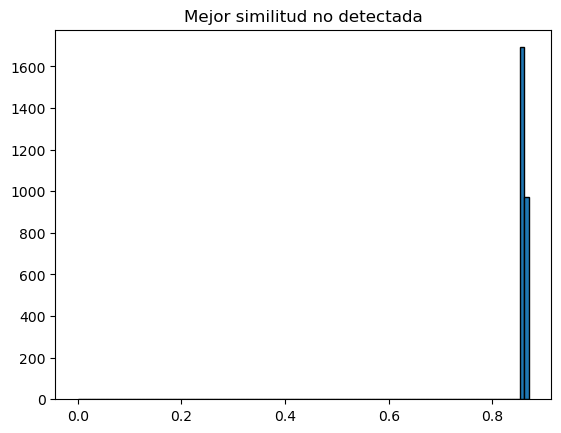

In [43]:
#Histograma de mejor similitud no detectada, con 10 bins
plt.hist(df["mejor_similitud"].dropna(), bins=100, edgecolor='black')
plt.title("Mejor similitud no detectada")  